# Aspect Based Sentiment Analysis

### Comentarios dentro de las categorías *positivo* y *negativo*

In [2]:
# cargamos el csv con los comentarios:
import pandas as pd
df = pd.read_csv('df_hoteles_vlc_comentarios.csv')
# mostramos las primeras filas del dataframe:
display(df.head())

  nacionalidad                             detalles_hab  noches  \
0       España  Habitación Meliá con 1 cama extragrande       1   
1       España                       Habitación Supreme       1   
2        Chile  Habitación Meliá con 1 cama extragrande       3   
3       España            Alojamiento The Level Supreme       3   
4         Perú                         Habitación Meliá       2   

                 personas                      comentario_general  \
0                  pareja                               Excelente   
1  Persona que viaja sola  Mi referente para alojarme en Valencia   
2                  pareja        Hotel funcional en lugar alejado   
3                 familia                          Solo perfecto!   
4                 familia                              Fantástico   

                                            positivo           negativo  nota  \
0  Todo la habitación súper amplia, la cama extra...                NaN  10.0   
1  Ya lo conocía de 

In [4]:
comentarios_positivos = df['positivo'].dropna().tolist() 
print(f"Hay {len(comentarios_positivos)} comentarios positivos.")
for i in range(min(5, len(comentarios_positivos))):
    print(f"Comentario positivo {i+1}:\n {comentarios_positivos[i]}\n\n")

Hay 31227 comentarios positivos.
Comentario positivo 1:
 Todo la habitación súper amplia, la cama extra grande y colchón y almohadas muy cómodas. 
El desayuno buffet excelente! 
Todo muy bien 😊


Comentario positivo 2:
 Ya lo conocía de anteriores estancias. Me encantan las plantas en altura, la tranquilidad, la comodidad de las camas, el desayuno y que tienen párking con puntos de recarga de vehículos eléctricos.


Comentario positivo 3:
 El lobby y cafeteria


Comentario positivo 4:
 Habitacion a la planta 24 (high level) - a este nivel hay atencion personalizada, tanto en recepcion (recepcion aparte) como en la zona restaurante (desayuno/comidas).
Subimos con un ascensor con vista al exterior - nuestra hija(4 años) se quedo impresionada ya que vivimos en una casa y el ascensor no es habitual para nosotros-


Comentario positivo 5:
 Habitación cómoda, la ubicación muy buena y el desayuno: Exelente!




In [5]:
comentarios_negativos = df['negativo'].dropna().tolist() 
print(f"Hay {len(comentarios_negativos)} comentarios negativos.")
for i in range(min(5, len(comentarios_negativos))):
    print(f"Comentario negativo {i+1}:\n {comentarios_negativos[i]}\n\n")

Hay 23325 comentarios negativos.
Comentario negativo 1:
 Ascensores lentos


Comentario negativo 2:
 Precio del desayuno


Comentario negativo 3:
 La distancia del centro


Comentario negativo 4:
 Está bastante alejado, pero ya se sabía.


Comentario negativo 5:
 Nada




### Número de comentarios por nacionalidad

In [6]:
nacionalidades = df['nacionalidad'].dropna().unique()
print(f"Hay {len(nacionalidades)} nacionalidades diferentes entre los clientes.")

# contamos las nacionalidades en general
count = {}

for nacionalidad in df['nacionalidad']:
    if nacionalidad in count:
        count[nacionalidad] += 1
    else:
        count[nacionalidad] = 1

print(f"Clientes de {len(count)} nacionalidades hicieron comentarios generales.")

# contamos las nacionalidades de los clientes que hicieron comentarios positivos
count_positivos = {}
df_comentarios_positivos = df[df['positivo'].notna()]
for nacionalidad in df_comentarios_positivos['nacionalidad']:
    if nacionalidad in count_positivos:
        count_positivos[nacionalidad] += 1
    else:
        count_positivos[nacionalidad] = 1

print(f"Clientes de {len(count_positivos)} nacionalidades hicieron comentarios positivos.")

# contamos las nacionalidades de los clientes que hicieron comentarios negativos
count_negativos = {}
df_comentarios_negativos = df[df['negativo'].notna()]
for nacionalidad in df_comentarios_negativos['nacionalidad']:
    if nacionalidad in count_negativos:
        count_negativos[nacionalidad] += 1
    else:
        count_negativos[nacionalidad] = 1


print(f"Clientes de {len(count_negativos)} nacionalidades hicieron comentarios negativos.")

Hay 159 nacionalidades diferentes entre los clientes.
Clientes de 160 nacionalidades hicieron comentarios generales.
Clientes de 147 nacionalidades hicieron comentarios positivos.
Clientes de 140 nacionalidades hicieron comentarios negativos.


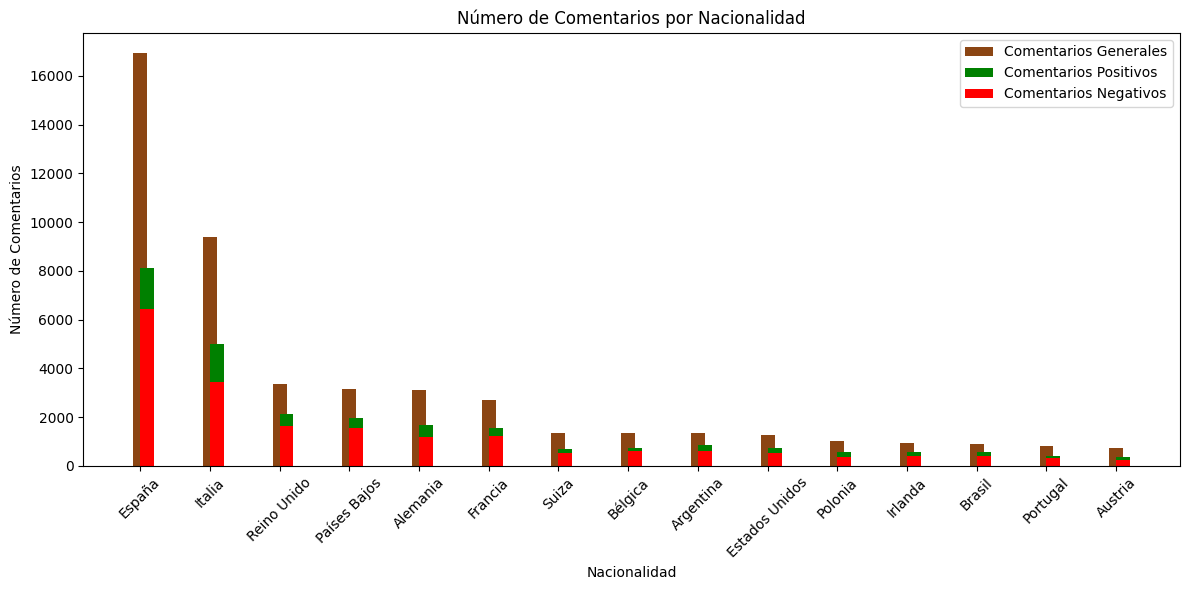

In [10]:
import matplotlib.pyplot as plt

# crear un gráfico de barras que para cada nacionalidad muestre el número de comentarios generales, positivos y negativos
# nos quedamos con las 15 nacionalidades que más comentarios generales han hecho
top_nacionalidades = sorted(count, key=count.get, reverse=True)[:15]
general_counts = [count[nacionalidad] for nacionalidad in top_nacionalidades]
positivos_counts = [count_positivos.get(nacionalidad, 0) for nacionalidad in top_nacionalidades]
negativos_counts = [count_negativos.get(nacionalidad, 0) for nacionalidad in top_nacionalidades]

x = range(len(top_nacionalidades))
plt.figure(figsize=(12, 6))
plt.bar(x, general_counts, width=0.2, label='Comentarios Generales', align='center', color='saddlebrown')
plt.bar(x, positivos_counts, width=0.2, label='Comentarios Positivos', align='edge', color='green')
plt.bar(x, negativos_counts, width=0.2, label='Comentarios Negativos', align='edge', color='red')
plt.xticks(x, top_nacionalidades, rotation=45)
plt.xlabel('Nacionalidad')
plt.ylabel('Número de Comentarios')
plt.title('Número de Comentarios por Nacionalidad')
plt.legend()
plt.tight_layout()
plt.show()


### Empezamos haciendo un análisis de sentimiento a los comentarios de los clientes anglosajones

In [14]:
# nos quedamos con los anglosajones
df_comentarios_negativos_anglosajones = df_comentarios_negativos[df_comentarios_negativos['nacionalidad'].isin(['Reino Unido', 'Estados Unidos', 'Irlanda'])]
df_comentarios_positivos_anglosajones = df_comentarios_positivos[df_comentarios_positivos['nacionalidad'].isin(['Reino Unido', 'Estados Unidos', 'Irlanda'])]

In [15]:
print(f"Hay {len(df_comentarios_negativos_anglosajones)} comentarios negativos de clientes anglosajones.")
print(f"Hay {len(df_comentarios_positivos_anglosajones)} comentarios positivos de clientes anglosajones.")

Hay 2571 comentarios negativos de clientes anglosajones.
Hay 3439 comentarios positivos de clientes anglosajones.
